#Epic 2: Data Collection & Preparation

**Activity 1. : Collect the dataset**

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("insurance_claims.csv")

df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


**Activity 2: Data Preparation**

In [3]:
df.isna().any()

,0
months_as_customer,False
age,False
policy_number,False
policy_bind_date,False
policy_state,False
policy_csl,False
policy_deductable,False
policy_annual_premium,False
umbrella_limit,False
insured_zip,False


In [5]:
df['_c39'].isna().sum()

np.int64(1000)

In [7]:
df = df.drop('_c39', axis=1)

In [10]:
IQR = []

IQR.append(df['age'].quantile(0.75) - df['age'].quantile(0.25))
IQR.append(df['policy_annual_premium'].quantile(0.75) - df['policy_annual_premium'].quantile(0.25))
IQR.append(df['umbrella_limit'].quantile(0.75) - df['umbrella_limit'].quantile(0.25))
IQR.append(df['total_claim_amount'].quantile(0.75) - df['total_claim_amount'].quantile(0.25))
IQR.append(df['property_claim'].quantile(0.75) - df['property_claim'].quantile(0.25))

In [11]:
upper = []

upper.append(df['age'].quantile(0.75) + 1.5 * (IQR[0]))
upper.append(df['policy_annual_premium'].quantile(0.75) + 1.5 * (IQR[1]))
upper.append(df['umbrella_limit'].quantile(0.75) + 1.5 * (IQR[2]))
upper.append(df['total_claim_amount'].quantile(0.75) + 1.5 * (IQR[3]))
upper.append(df['property_claim'].quantile(0.75) + 1.5 * (IQR[4]))

upper

[np.float64(62.0),
 np.float64(1904.8262500000003),
 np.float64(0.0),
 np.float64(113762.5),
 np.float64(20545.0)]

In [12]:
df_num_features = df.select_dtypes(include=np.number)
df_num_features.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip',
       'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
       'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim',
       'auto_year'],
      dtype='object')

months_as_customer


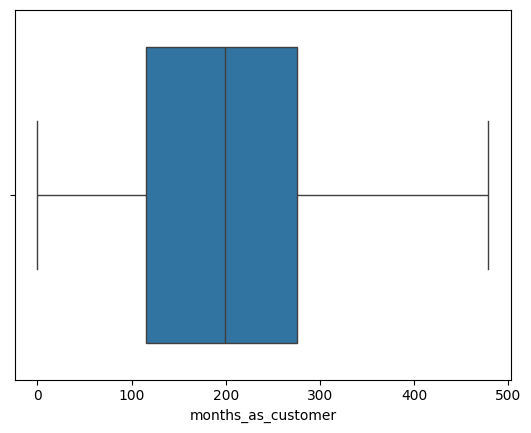

age


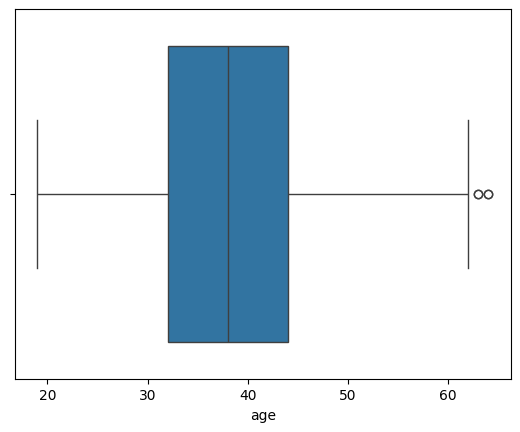

policy_number


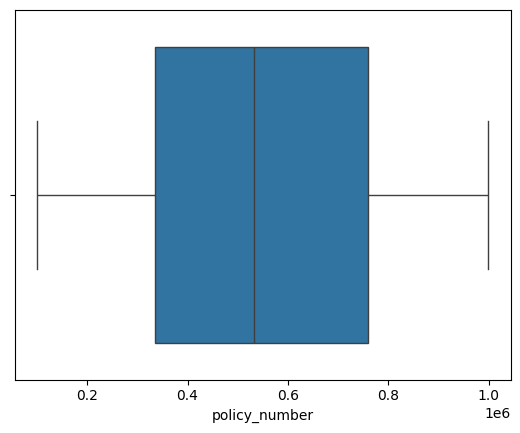

policy_deductable


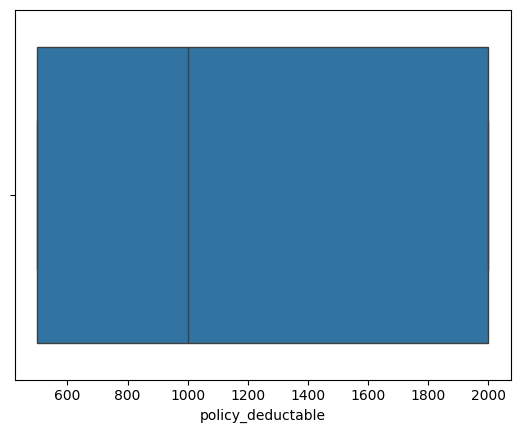

policy_annual_premium


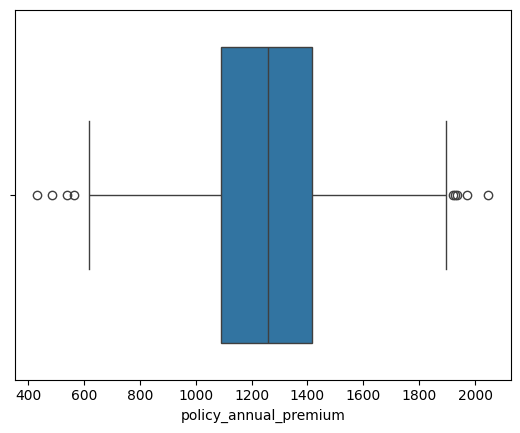

umbrella_limit


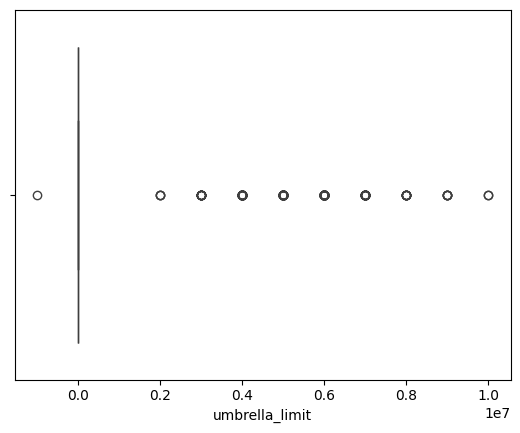

insured_zip


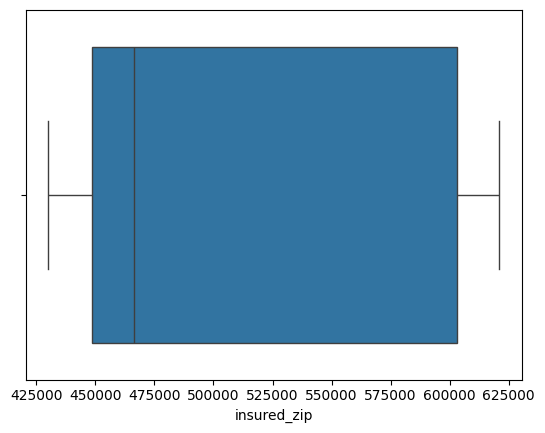

capital-gains


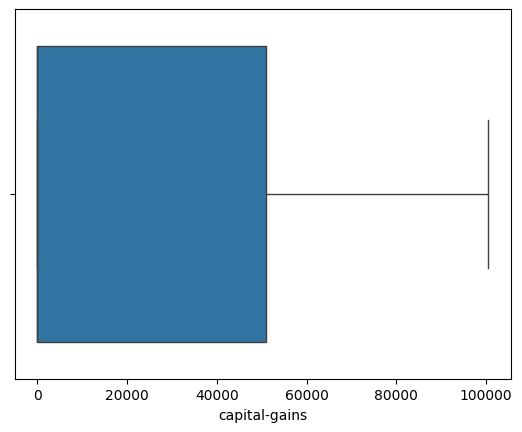

capital-loss


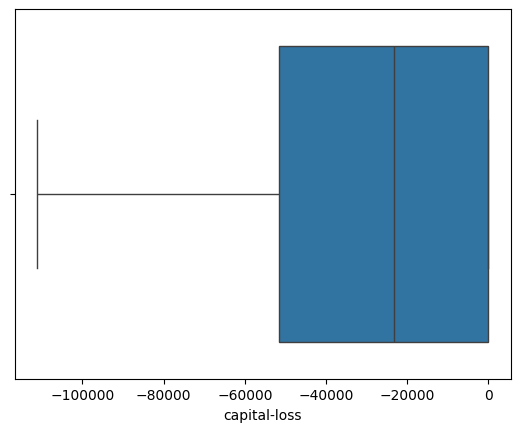

incident_hour_of_the_day


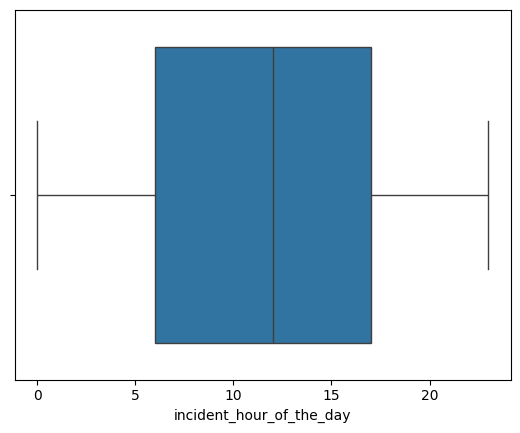

number_of_vehicles_involved


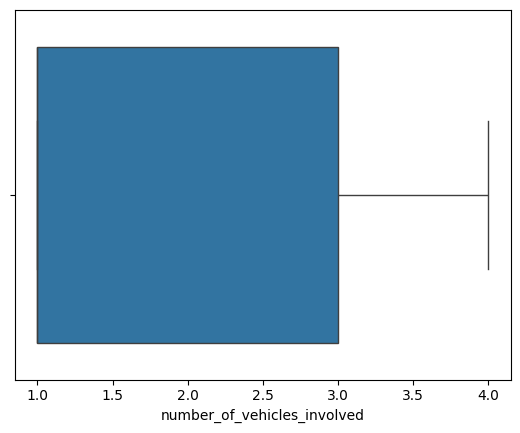

bodily_injuries


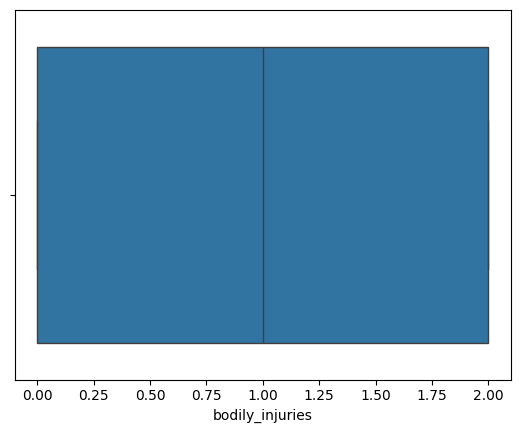

witnesses


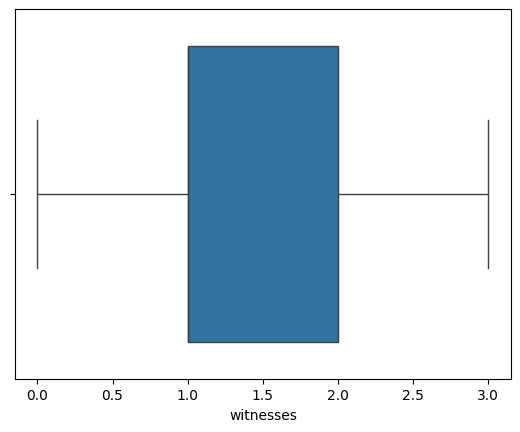

total_claim_amount


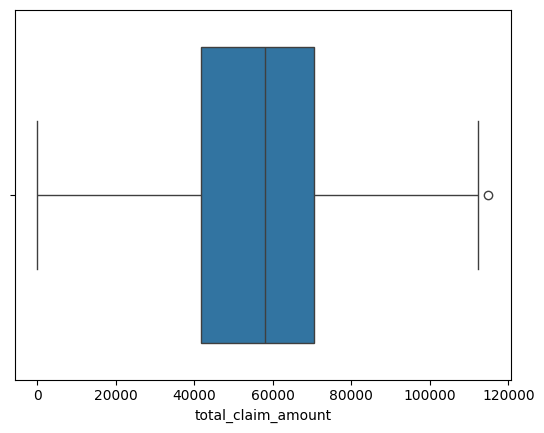

injury_claim


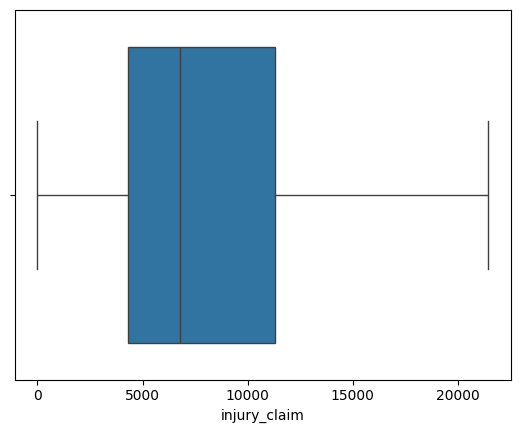

property_claim


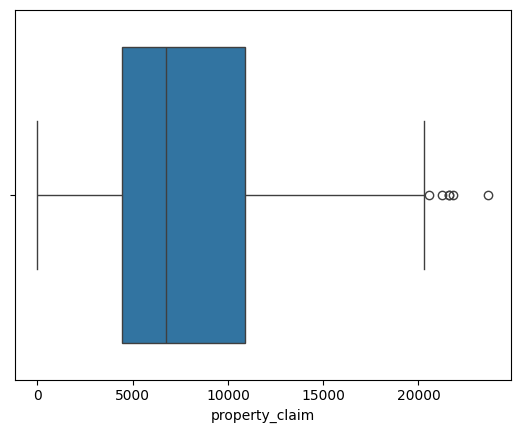

vehicle_claim


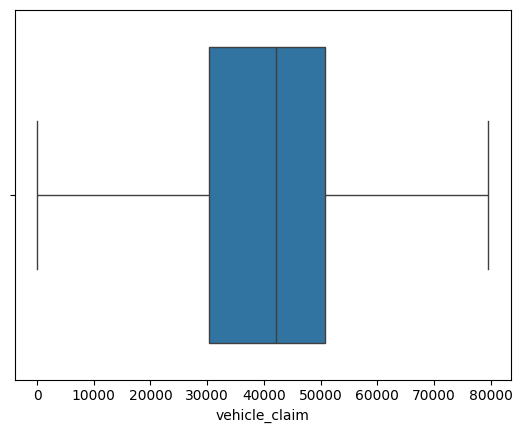

auto_year


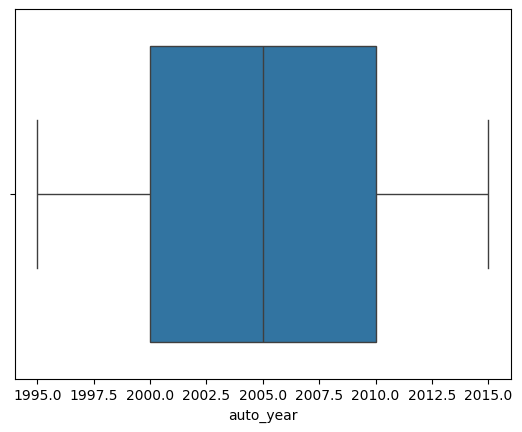

In [13]:
for k in df_num_features.columns:
    print(k)
    sns.boxplot(data=df, x=k)
    plt.show()

# Epic 3: Exploratory Data Analysis

**Story2.1-Univariate Analysis**

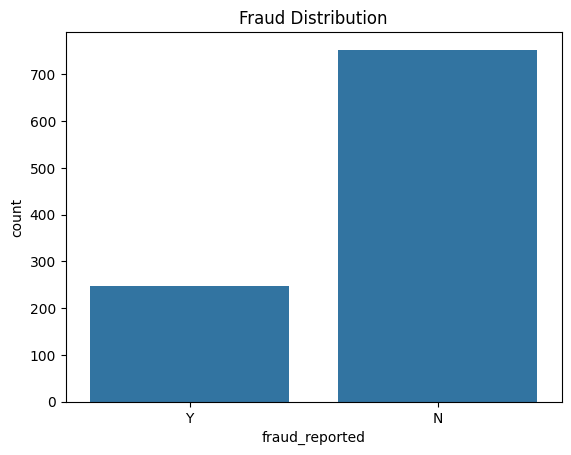

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fraud_reported',data=df)
plt.title("Fraud Distribution")
plt.show()

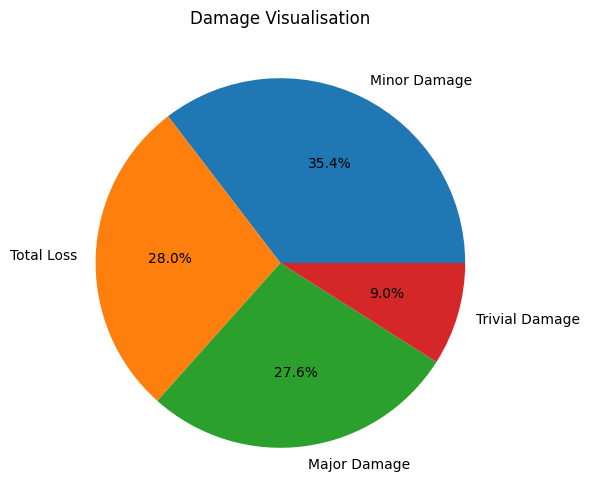

In [16]:
df['incident_severity'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title("Damage Visualisation")
plt.ylabel("")
plt.show()

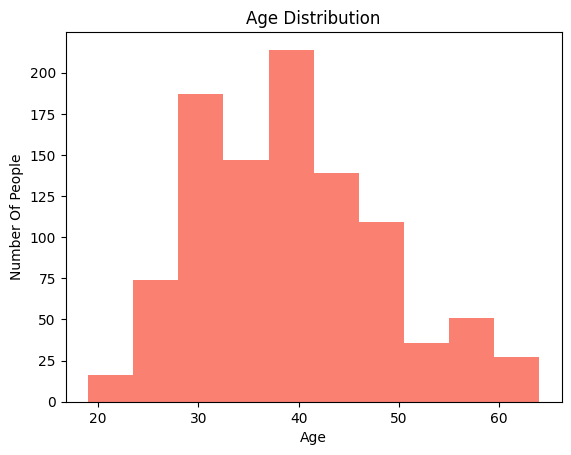

In [17]:
plt.hist(df['age'],bins=10,color='salmon')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number Of People")
plt.show()

**Story 2.3: Multivariate analysis**

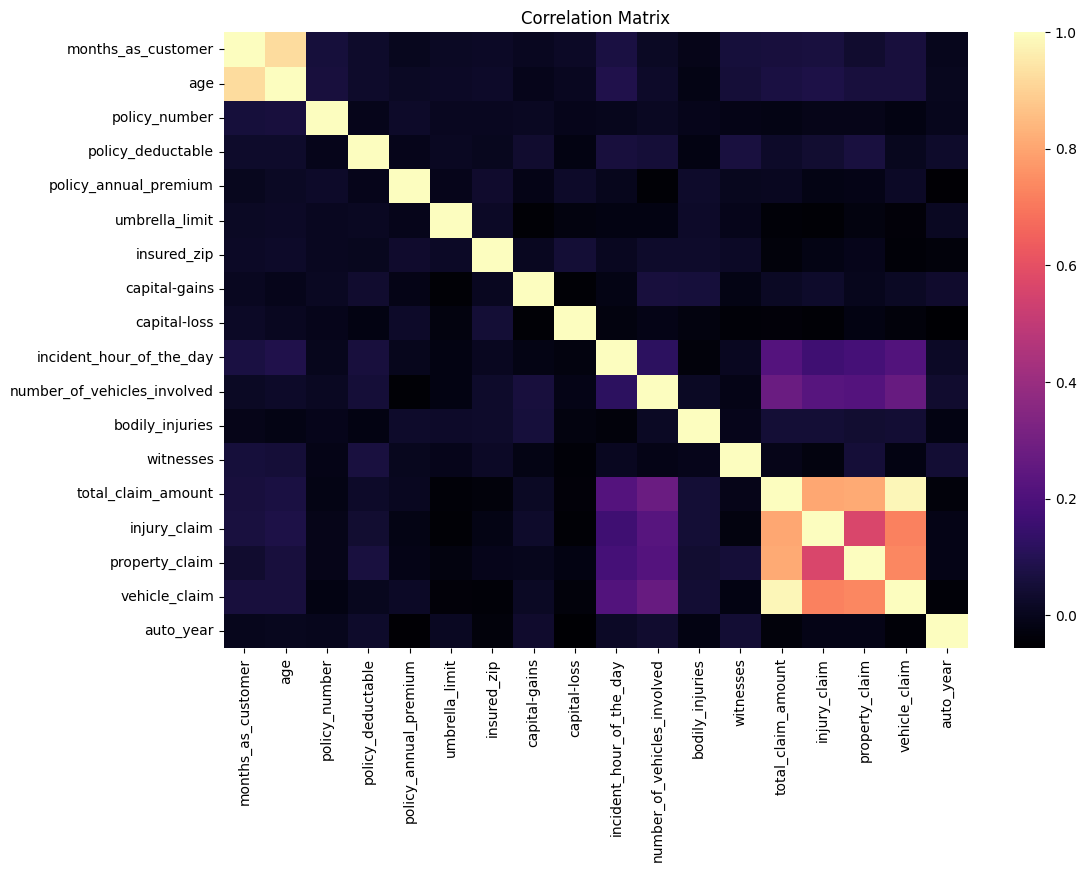

In [18]:
plt.figure(figsize=(12,8))
corr_matrix=df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix,cmap='magma')
plt.title("Correlation Matrix")
plt.show()

In [19]:
daata1 = df.copy()

**Encoding the Categorical Features**

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in daata1.columns:
    if daata1[col].dtype == 'O':
        daata1[col] = le.fit_transform(daata1[col])

In [26]:
# Splitting features and target
x = daata1.iloc[:, 0:30]   # Features
y = daata1['fraud_reported']    # Target

**Train-Test Split.**


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

**Scaling**

In [28]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

# Scaling Training data
X_train = std_scaler.fit_transform(X_train)
X_train = pd.DataFrame(X_train, columns=x.columns)

# Scaling Testing data
X_test = std_scaler.transform(X_test)
X_test = pd.DataFrame(X_test, columns=x.columns)

# Epic 4-Model Building

**Decision tree model**

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize Decision Tree
dtc = DecisionTreeClassifier(random_state=0)
dtc.fit(X_train, y_train)

# Predict on Test data
y_pred = dtc.predict(X_test)

# Calculate accuracy
dtc_train_acc = accuracy_score(y_train, dtc.predict(X_train))
dtc_test_acc = accuracy_score(y_test, y_pred)

print(f"Decision Tree Training Accuracy: {dtc_train_acc*100:.2f}%")
print(f"Decision Tree Testing Accuracy: {dtc_test_acc*100:.2f}%")

# Optional: Confusion Matrix & Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Decision Tree Training Accuracy: 100.00%
Decision Tree Testing Accuracy: 81.00%
Confusion Matrix:
 [[129  14]
 [ 24  33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87       143
           1       0.70      0.58      0.63        57

    accuracy                           0.81       200
   macro avg       0.77      0.74      0.75       200
weighted avg       0.80      0.81      0.80       200



**Random forest model**

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=0)  # 100 trees
rf.fit(X_train, y_train)

# Predict on Test set
rf_pred = rf.predict(X_test)

# Accuracy
rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Training Accuracy: {rf_train_acc*100:.2f}%")
print(f"Random Forest Testing Accuracy: {rf_test_acc*100:.2f}%")

# Confusion Matrix & Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Random Forest Training Accuracy: 100.00%
Random Forest Testing Accuracy: 77.50%
Confusion Matrix:
 [[138   5]
 [ 40  17]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.97      0.86       143
           1       0.77      0.30      0.43        57

    accuracy                           0.78       200
   macro avg       0.77      0.63      0.65       200
weighted avg       0.77      0.78      0.74       200



**KNN model**

In [31]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=30)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred))

KNN Confusion Matrix:
 [[143   0]
 [ 57   0]]

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.71      1.00      0.83       143
           1       0.00      0.00      0.00        57

    accuracy                           0.71       200
   macro avg       0.36      0.50      0.42       200
weighted avg       0.51      0.71      0.60       200



**Logistic Regression model**

In [32]:
from sklearn.linear_model import LogisticRegressionCV

lg = LogisticRegressionCV(solver='lbfgs', max_iter=5000, cv=10)
lg.fit(X_train, y_train)

lrg_pred = lg.predict(X_test)

print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, lrg_pred))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, lrg_pred))

Logistic Regression Confusion Matrix:
 [[132  11]
 [ 38  19]]

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.92      0.84       143
           1       0.63      0.33      0.44        57

    accuracy                           0.76       200
   macro avg       0.70      0.63      0.64       200
weighted avg       0.74      0.76      0.73       200



**Naïve Bayes model**

In [33]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
model_2 = gnb.fit(X_train, y_train)

predict_log = model_2.predict(X_test)

print("GaussianNB Training Accuracy:", 100 * accuracy_score(y_train, model_2.predict(X_train)))
print("GaussianNB Testing Accuracy:", 100 * accuracy_score(y_test, predict_log))

GaussianNB Training Accuracy: 79.125
GaussianNB Testing Accuracy: 73.0


**SVM model**

In [34]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

svc_train_acc = accuracy_score(y_train, svc.predict(X_train))
svc_test_acc = accuracy_score(y_test, y_pred)

print(f"SVC Training Accuracy: {svc_train_acc*100:.2f}%")
print(f"SVC Testing Accuracy: {svc_test_acc*100:.2f}%")
print("SVC Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nSVC Classification Report:\n", classification_report(y_test, y_pred))

SVC Training Accuracy: 87.12%
SVC Testing Accuracy: 71.00%
SVC Confusion Matrix:
 [[141   2]
 [ 56   1]]

SVC Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.99      0.83       143
           1       0.33      0.02      0.03        57

    accuracy                           0.71       200
   macro avg       0.52      0.50      0.43       200
weighted avg       0.61      0.71      0.60       200



#Testing the model


In [35]:

b_dtc = dtc


single_input = [[328, 521585, 2012, 12, 250, 1000, 1406.91, 5600,
                 1, 100, 25, 25, 50000, 0, 120, 23, 56, 52,
                 1, 123, 2, 3, 1, 0, 2, 1, 150000, 2, 25, 2002]]


prediction = b_dtc.predict(single_input)

print("Prediction (0 = No Fraud, 1 = Fraud):", prediction)

Prediction (0 = No Fraud, 1 = Fraud): [1]


#Epic 5: Performance Testing & Hyperparameter Tuning

**Compare the model**

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def comparison(X_test, y_test):
    print("-" * 50)
    print("Logistic Regression Accuracy: ", 100 * accuracy_score(y_test, lrg_pred))
    print("-" * 50)

    print("KNN Accuracy: ", 100 * accuracy_score(y_test, knn.predict(X_test)))
    print("-" * 50)

    print("SVM Accuracy: ", 100 * accuracy_score(y_test, svc.predict(X_test)))
    print("-" * 50)

    print("Naive-Bayes Accuracy: ", 100 * accuracy_score(y_test, model_2.predict(X_test)))
    print("-" * 50)

    print("Decision Tree Accuracy: ", 100 * accuracy_score(y_test, b_dtc.predict(X_test)))
    print("-" * 50)

    print("Random Forest Accuracy: ", 100 * accuracy_score(y_test, rf.predict(X_test)))
    print("-" * 50)

# Run comparison
comparison(X_test, y_test)

--------------------------------------------------
Logistic Regression Accuracy:  75.5
--------------------------------------------------
KNN Accuracy:  71.5
--------------------------------------------------
SVM Accuracy:  71.0
--------------------------------------------------
Naive-Bayes Accuracy:  73.0
--------------------------------------------------
Decision Tree Accuracy:  81.0
--------------------------------------------------
Random Forest Accuracy:  77.5
--------------------------------------------------


In [37]:
from sklearn.metrics import accuracy_score

def quick_comparison(X_train, X_test, y_train, y_test):
    models = {
        "Logistic Regression": lg,
        "KNN": knn,
        "SVM": svc,
        "Naive Bayes": model_2,
        "Decision Tree": dtc,
        "Random Forest": rf
    }

    for name, model in models.items():
        # Predict test set
        y_test_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)

        print("-" * 50)
        print(f"{name} Performance:")
        print(f"Training Accuracy: {100 * accuracy_score(y_train, y_train_pred):.2f}%")
        print(f"Test Accuracy: {100 * accuracy_score(y_test, y_test_pred):.2f}%\n")

# Run the quick comparison
quick_comparison(X_train, X_test, y_train, y_test)

--------------------------------------------------
Logistic Regression Performance:
Training Accuracy: 80.12%
Test Accuracy: 75.50%

--------------------------------------------------
KNN Performance:
Training Accuracy: 76.25%
Test Accuracy: 71.50%

--------------------------------------------------
SVM Performance:
Training Accuracy: 87.12%
Test Accuracy: 71.00%

--------------------------------------------------
Naive Bayes Performance:
Training Accuracy: 79.12%
Test Accuracy: 73.00%

--------------------------------------------------
Decision Tree Performance:
Training Accuracy: 100.00%
Test Accuracy: 81.00%

--------------------------------------------------
Random Forest Performance:
Training Accuracy: 100.00%
Test Accuracy: 77.50%



**Activity 2: Comparing model accuracy before & after applying hyperparameter tuning**

In [38]:
from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(b_dtc, X_train, y_train, cv=10)


print("Cross-validation scores for each fold:", cv_scores)

print(f"Average Accuracy: {cv_scores.mean():.4f}")

Cross-validation scores for each fold: [0.8625 0.7875 0.7875 0.8    0.825  0.725  0.8125 0.8375 0.7875 0.85  ]
Average Accuracy: 0.8075


In [44]:

comparison(X_test, y_test)


from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(b_dtc, X_train, y_train, cv=10)
print("Cross-validation scores:", cv_scores)
print(f"Average Accuracy: {cv_scores.mean():.4f}")


import joblib
joblib.dump(b_dtc, 'best_model.pkl')
print("Model saved as best_model.pkl")

--------------------------------------------------
Logistic Regression Accuracy:  75.5
--------------------------------------------------
KNN Accuracy:  71.5
--------------------------------------------------
SVM Accuracy:  71.0
--------------------------------------------------
Naive-Bayes Accuracy:  73.0
--------------------------------------------------
Decision Tree Accuracy:  81.0
--------------------------------------------------
Random Forest Accuracy:  77.5
--------------------------------------------------
Cross-validation scores: [0.8625 0.7875 0.7875 0.8    0.825  0.725  0.8125 0.8375 0.7875 0.85  ]
Average Accuracy: 0.8075
Model saved as best_model.pkl
